# DA-6 EmbeddingSearchTool — Demo

展示 DA-6 目前實作的功能：上傳文件文字 → 經 **Module 07**（bge-m3）嵌入 →
寫入 Qdrant → 語意最近鄰搜尋。

**前置**
- Module 07 dev（v314）inference API 可達：`http://localhost:9998`（`bge-m3` 已註冊）。
- 從 host 執行；`pip install httpx qdrant-client smolagents pymupdf matplotlib`。
- DA-6 目前是**工具層**（尚無 `/process` 服務端點，那屬 DA-1），因此本 demo 直接
  驅動 `EmbeddingSearchTool`。`forward()` 即等同未來 `/process?task=search` 的行為。

可直接當 notebook 開，或 `python tests/demo_da6.py` 逐格執行。

In [1]:
import os
import sys

# 讓 `import app...` 解析到模組根目錄（tests/ 的上一層）
try:
    _ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:  # notebook：__file__ 不存在時退回 cwd
    _ROOT = os.getcwd()
    if os.path.basename(_ROOT) == "tests":
        _ROOT = os.path.dirname(_ROOT)
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from qdrant_client import QdrantClient  # noqa: E402
from app.tools.embedding_search import EmbeddingSearchConfig, EmbeddingSearchTool  # noqa: E402

INFERENCE_URL = os.environ.get("DA_AI_LIFECYCLE_URL", "http://localhost:9998")  # v314 dev
EMBED_MODEL = os.environ.get("DA_EMBED_MODEL", "bge-m3")
# 預設用內嵌 :memory: Qdrant（乾淨、可重跑）。設 DA_DEMO_REAL_QDRANT=1 改寫入
# 共用 raptor-qdrant:6333（可在 http://localhost:6333/dashboard 瀏覽 points）。
USE_REAL_QDRANT = os.environ.get("DA_DEMO_REAL_QDRANT", "0") == "1"

cfg = EmbeddingSearchConfig(
    ai_lifecycle_url=INFERENCE_URL,
    embed_model=EMBED_MODEL,
    qdrant_url="http://localhost:6333",
    collection="doc_agent_demo",
    vector_size=1024,
    chunk_size=400,
    chunk_overlap=60,
)
qdrant = QdrantClient(url=cfg.qdrant_url) if USE_REAL_QDRANT else QdrantClient(location=":memory:")
if USE_REAL_QDRANT and qdrant.collection_exists(cfg.collection):
    qdrant.delete_collection(cfg.collection)  # 乾淨重跑

tool = EmbeddingSearchTool(config=cfg, qdrant_client=qdrant)
print("✅ tool ready")
print("   embeddings :", INFERENCE_URL, f"(model={EMBED_MODEL})")
print("   qdrant     :", "real localhost:6333" if USE_REAL_QDRANT else ":memory:")

✅ tool ready
   embeddings : http://localhost:9998 (model=bge-m3)
   qdrant     : :memory:


## 1. 索引兩份文件
一份是關於 Scope 3 排放的 3 頁 PDF，另一份是無關的引擎冷卻系統手冊 —— 用來展示
跨文件檢索能挑出正確來源。

In [2]:
import fitz  # uv pip install PyMuPDF

PDF = os.path.join(_ROOT, "tests", "fixtures", "scope3_emissions.pdf")
scope3_text = "\n".join(page.get_text() for page in fitz.open(PDF))

cooling_text = (
    "Engine Cooling System Overview. "
    "The cooling system circulates liquid coolant through the engine block and the radiator. "
    "A thermostat regulates coolant flow to keep the engine at its optimal operating temperature. "
    "The water pump drives coolant circulation, while the radiator fan dissipates heat to the air. "
    "Low coolant level or a failed thermostat can cause the engine to overheat."
)

n1 = tool.index_document(scope3_text, source="scope3_emissions.pdf")
n2 = tool.index_document(cooling_text, source="cooling_system_manual.txt")
print(f"indexed {n1} chunk(s) from scope3_emissions.pdf")
print(f"indexed {n2} chunk(s) from cooling_system_manual.txt")

indexed 7 chunk(s) from scope3_emissions.pdf
indexed 1 chunk(s) from cooling_system_manual.txt


## 2. 語意搜尋（跨文件）
兩個 query 應各自命中對應文件。

In [3]:
def show(query: str, top_k: int = 3) -> None:
    print(f"\nQ: {query!r}")
    for r in tool.search(query, top_k=top_k):
        print(f"   {r['score']:.3f}  [{r['source']:<28}]  {r['text'][:70].strip()}…")


show("scope 3 supplier emissions")
show("how does the engine radiator and coolant work")


Q: 'scope 3 supplier emissions'
   0.745  [scope3_emissions.pdf        ]  from suppliers and is typically the single largest source. Scope 3 Sup…
   0.699  [scope3_emissions.pdf        ]  Scope 3 Greenhouse Gas Emissions — Overview Scope 3 emissions are all…
   0.616  [scope3_emissions.pdf        ]  sold products) are frequently material downstream hotspots. Transparen…

Q: 'how does the engine radiator and coolant work'
   0.748  [cooling_system_manual.txt   ]  Engine Cooling System Overview. The cooling system circulates liquid c…
   0.350  [scope3_emissions.pdf        ]  often exceeding 70 percent of company-wide emissions. The GHG Protocol…
   0.349  [scope3_emissions.pdf        ]  material substitution, and logistics optimisation. Setting supplier em…


## 3. `/process?task=search` 行為：同一次呼叫先索引、再搜尋
`forward()` 就是未來 `/process?task=search` 走的路徑 —— 上傳當下文件即索引，並與
先前所有文件一起被搜尋。

In [4]:
out = tool.forward(
    query="scope 3 supplier emissions",
    document_text="Appendix B. This appendix breaks down Scope 3 supplier emissions by GHG Protocol category.",
    source="appendix_B.txt",
    top_k=3,
)
print("indexed_chunks (this call):", out["indexed_chunks"])
for r in out["results"]:
    print(f"   {r['score']:.3f}  [{r['source']:<28}]  {r['text'][:70].strip()}…")

indexed_chunks (this call): 1
   0.745  [scope3_emissions.pdf        ]  from suppliers and is typically the single largest source. Scope 3 Sup…
   0.699  [scope3_emissions.pdf        ]  Scope 3 Greenhouse Gas Emissions — Overview Scope 3 emissions are all…
   0.659  [appendix_B.txt              ]  Appendix B. This appendix breaks down Scope 3 supplier emissions by GH…


## 4. 重傳去重（idempotent）
同來源、同內容重傳不會灌爆 collection（point id = 內容 hash）。

In [5]:
before = tool._qdrant.count(collection_name=cfg.collection).count
tool.index_document(scope3_text, source="scope3_emissions.pdf")  # 完全相同的內容
after = tool._qdrant.count(collection_name=cfg.collection).count
print(f"points before re-index: {before} | after: {after} → "
      f"{'no duplicates ✅' if before == after else 'DUPLICATED ❌'}")

points before re-index: 9 | after: 9 → no duplicates ✅


## 5. 驗收：DA-6 AC —— top score > 0.7

In [6]:
top = tool.search("scope 3 supplier emissions", top_k=1)[0]
verdict = "PASS ✅" if top["score"] > 0.7 else "FAIL ❌"
print(f"top score = {top['score']:.3f}  ({verdict} threshold 0.7)")
print(f"top source = {top['source']}")

top score = 0.745  (PASS ✅ threshold 0.7)
top source = scope3_emissions.pdf


## 6.（選用）top-k 分數長條圖

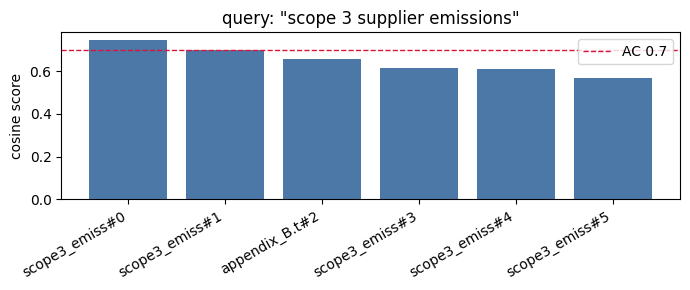

In [9]:
try:
    try:  # notebook 內顯示 inline；當純 script 執行時 get_ipython 不存在，略過
        get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821
    except NameError:
        pass
    import matplotlib.pyplot as plt

    hits = tool.search("scope 3 supplier emissions", top_k=6)
    labels = [f"{h['source'][:12]}#{i}" for i, h in enumerate(hits)]
    plt.figure(figsize=(7, 3))
    plt.bar(labels, [h["score"] for h in hits], color="#4C78A8")
    plt.axhline(0.7, color="crimson", ls="--", lw=1, label="AC 0.7")
    plt.ylabel("cosine score")
    plt.title('query: "scope 3 supplier emissions"')
    plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("(matplotlib 未安裝，略過圖表)")